In [83]:
import numpy as np
import pandas as pd

In [84]:
sp500 = pd.read_csv("/sp500_raw.csv", index_col = 0, parse_dates = True, skiprows = [1,2])
vix = pd.read_csv("/vix_raw.csv", index_col = 0, parse_dates = True, skiprows = [1,2])
print(vix.head(5))
print(sp500.head(5))

                Close       High        Low       Open  Volume
Price                                                         
1990-01-02  17.240000  17.240000  17.240000  17.240000       0
1990-01-03  18.190001  18.190001  18.190001  18.190001       0
1990-01-04  19.219999  19.219999  19.219999  19.219999       0
1990-01-05  20.110001  20.110001  20.110001  20.110001       0
1990-01-08  20.260000  20.260000  20.260000  20.260000       0
                 Close        High         Low        Open     Volume
Price                                                                
1990-01-02  359.690002  359.690002  351.980011  353.399994  162070000
1990-01-03  358.760010  360.589996  357.890015  359.690002  192330000
1990-01-04  355.670013  358.760010  352.890015  358.760010  177000000
1990-01-05  352.200012  355.670013  351.350006  355.670013  158530000
1990-01-08  353.790009  354.239990  350.540009  352.200012  140110000


In [85]:
vix = vix[["Close"]].rename(columns={"Close": "VIX Price"})
vix.index.name = "Date"

sp500 = sp500[["Close"]].rename(columns={"Close": "SP500 Price"})
sp500.index.name = "Date"

print(vix.head())
print(sp500.head())

            VIX Price
Date                 
1990-01-02  17.240000
1990-01-03  18.190001
1990-01-04  19.219999
1990-01-05  20.110001
1990-01-08  20.260000
            SP500 Price
Date                   
1990-01-02   359.690002
1990-01-03   358.760010
1990-01-04   355.670013
1990-01-05   352.200012
1990-01-08   353.790009


In [86]:
df = pd.concat([sp500, vix], axis = 1, join = "inner")
df = df.dropna()

In [87]:
print(df.head(5))
print(df.shape)


            SP500 Price  VIX Price
Date                              
1990-01-02   359.690002  17.240000
1990-01-03   358.760010  18.190001
1990-01-04   355.670013  19.219999
1990-01-05   352.200012  20.110001
1990-01-08   353.790009  20.260000
(9227, 2)


In [88]:
print(len(vix), len(sp500), len(df))

9228 9227 9227


In [89]:
df["sp500_logreturns"] = np.log(df["SP500 Price"])-np.log(df["SP500 Price"]).shift(1)
df["sp500_logreturns"] = df["sp500_logreturns"]*100
df.head()

,SP500 Price,VIX Price,sp500_logreturns
Date,,,
1990-01-02,359.690002,17.240000,NaN
1990-01-03,358.760010,18.190001,-0.258889
1990-01-04,355.670013,19.219999,-0.865030
1990-01-05,352.200012,20.110001,-0.980414
1990-01-08,353.790009,20.260000,0.450431


In [90]:
import matplotlib.pyplot as plt

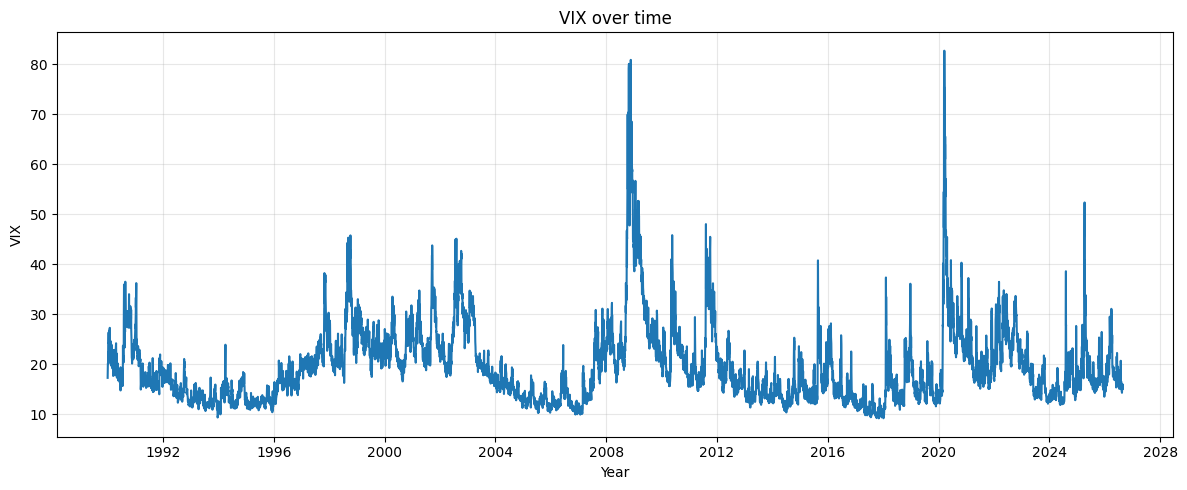

In [98]:
plt.figure(figsize = (12,5))
plt.plot(df["VIX Price"])
plt.title("VIX over time")
plt.xlabel("Year")
plt.ylabel("VIX")
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

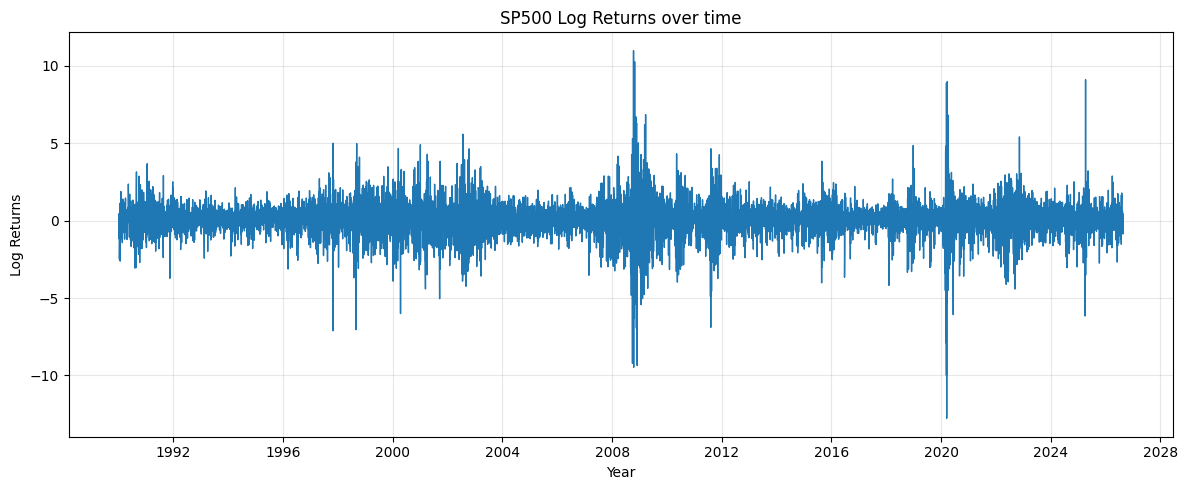

In [103]:
plt.figure(figsize = (12,5))
plt.plot(df["sp500_logreturns"], linewidth = 1)
plt.title("SP500 Log Returns over time")
plt.xlabel("Year")
plt.ylabel("Log Returns")
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

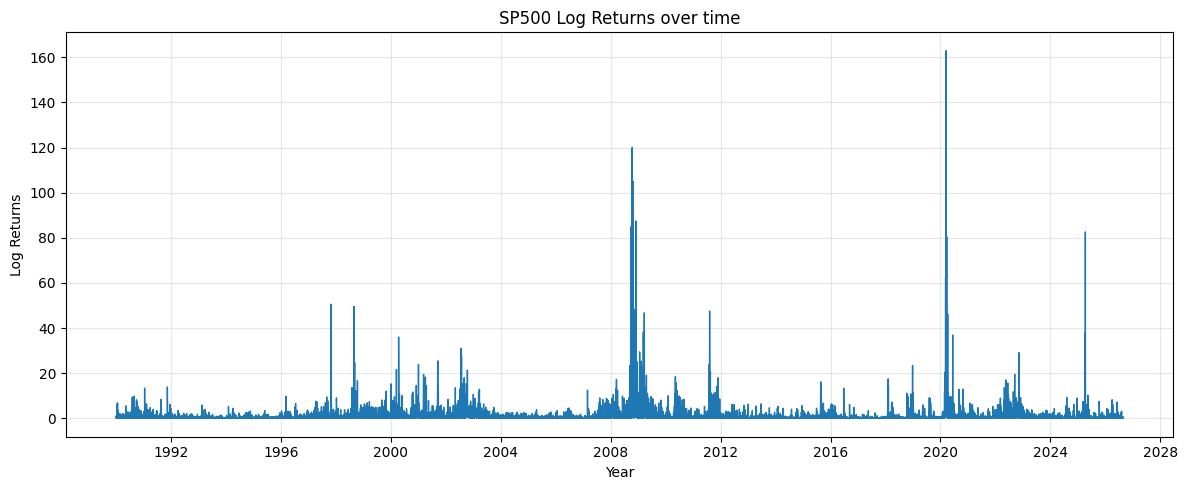

In [104]:
plt.figure(figsize = (12,5))
plt.plot(df["sp500_logreturns"]*df['sp500_logreturns'], linewidth = 1)
plt.title("SP500 Log Returns over time")
plt.xlabel("Year")
plt.ylabel("Log Returns")
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

In [106]:
desc_stats = df[["VIX Price", "sp500_logreturns"]].describe()
print(desc_stats)

         VIX Price  sp500_logreturns
count  9227.000000       9226.000000
mean     19.442863          0.033171
std       7.731647          1.134222
min       9.140000        -12.765220
25%      13.985000         -0.442176
50%      17.610001          0.059765
75%      22.705000          0.570430
max      82.690002         10.957197
